In [1]:
# 필수 라이브러리 임포트 및 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import nltk
from datetime import datetime
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize

# 시각화 스타일 설정
plt.style.use('ggplot')

# 한글 폰트 설정 (OS별 자동 감지)
import platform
from matplotlib import font_manager, rc

try:
    system_name = platform.system()
    if system_name == 'Windows':
        # 맑은 고딕 (Malgun Gothic) 시도
        font_path = "c:/Windows/Fonts/malgun.ttf"
        if os.path.exists(font_path):
            font_name = font_manager.FontProperties(fname=font_path).get_name()
            rc('font', family=font_name)
            print(f"✅ Windows Environment: '{font_name}' font (Malgun Gothic) selected.")
        else:
            # 폰트 파일 경로가 다를 경우 이름으로 직접 설정 시도
            rc('font', family='Malgun Gothic') 
            print("✅ Windows Environment: 'Malgun Gothic' font selected (by name).")
            
    elif system_name == 'Darwin': # Mac
        rc('font', family='AppleGothic')
        print("✅ Mac Environment: 'AppleGothic' font selected.")
    else: # Linux or other
        rc('font', family='NanumGothic')
        print("✅ Linux/Other: Tried 'NanumGothic'.")

    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    
except Exception as e:
    print(f"⚠️ Font Setting Failed: {e}")
    print("Using default font. Korean characters may not display correctly.")

# NLTK 데이터 다운로드 (최초 1회 필요)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    try:
        nltk.download('punkt')
        nltk.download('punkt_tab')
        print("✅ NLTK Data Downloaded.")
    except Exception as e:
        print(f"⚠️ NLTK Download Failed: {e}")

pd.set_option('display.max_columns', None)

print("✅ Libraries Loaded & Configured")

✅ Windows Environment: 'Malgun Gothic' font (Malgun Gothic) selected.
✅ Libraries Loaded & Configured


## 데이터 로딩 및 기본 전처리 (Loading & Basic Prep)
3가지 원본 JSON 데이터를 로드하고, 중첩된 구조(Properties, ID 등)를 평탄화합니다.

In [2]:
data_dir = '../data/'
file_usage = os.path.join(data_dir, '1. 사용자별 사용량 데이터.json')
file_client = os.path.join(data_dir, '2. 사용자 클라이언트 데이터.json')
file_event = os.path.join(data_dir, '3. 이벤트 데이터.json')

def load_and_preprocess():
    print("🔄 Loading Data...")
    
    # 1. Usage Data
    df1 = pd.read_json(file_usage, encoding='utf-8-sig')
    if '_id' in df1.columns:
        df1['_id'] = df1['_id'].apply(lambda x: x.get('$oid') if isinstance(x, dict) else x)
    if 'recent_execution_date' in df1.columns:
        df1['recent_execution_date'] = df1['recent_execution_date'].apply(lambda x: x.get('$date') if isinstance(x, dict) else x)
        df1['recent_execution_date'] = pd.to_datetime(df1['recent_execution_date'])
    df1.rename(columns={'_id': 'user_id_usage'}, inplace=True)
    
    # 2. Client Data
    df2 = pd.read_json(file_client, lines=True, encoding='utf-8-sig')
    if 'properties' in df2.columns:
        client_props = pd.json_normalize(df2['properties'])
        if 'distinct_id' in client_props.columns: # 중복 방지
            client_props.drop('distinct_id', axis=1, inplace=True)
        df2 = pd.concat([df2.drop('properties', axis=1), client_props], axis=1)

    # 3. Event Data
    df3 = pd.read_json(file_event, lines=True, encoding='utf-8-sig')
    if 'time' in df3.columns:
        df3['datetime'] = pd.to_datetime(df3['time'], unit='s', utc=True).dt.tz_convert('Asia/Seoul')
    if 'properties' in df3.columns:
        event_props = pd.json_normalize(df3['properties'])
        # 불필요한 중복 컬럼 제거
        for c in ['distinct_id', 'user_id', 'time']:
            if c in event_props.columns:
                event_props.drop(c, axis=1, inplace=True)
        df3 = pd.concat([df3.drop('properties', axis=1), event_props], axis=1)
        
    print(f"✅ Data Loaded. Shapes: Usage{df1.shape}, Client{df2.shape}, Event{df3.shape}")
    return df1, df2, df3

try:
    df_usage, df_client, df_event = load_and_preprocess()
except Exception as e:
    print(f"❌ Error loading data: {e}")

🔄 Loading Data...
✅ Data Loaded. Shapes: Usage(399, 3), Client(6695, 30), Event(62097, 81)


## 데이터 병합 (Master Table Creation)
- 사용자 정보(`Usage` + `Client`)와 로그 정보(`Event`)를 `distinct_id` 또는 `user_id`를 기준으로 하나로 합칩니다.
- 이를 통해 **"어떤 환경(OS/Browser)을 가진 사용자가 어떤 행동(Event)을 했는지"** 교차 분석이 가능해집니다.

In [3]:
print("🔄 Merging Dataframes...")
try:
    # 1. User Merge (Usage + Client)
    # df_usage의 user_id_usage와 df_client의 distinct_id 또는 user_id 연결 시도
    # 여기서는 df_client가 'distinct_id'를 가지고 있으므로 이를 사용
    user_merged = pd.merge(df_client, df_usage, left_on='distinct_id', right_on='user_id_usage', how='left')
    
    # 2. Key Mapping for Full Merge
    # df_event: 'distinct_id'
    # user_merged: 'distinct_id'
    full_merged = pd.merge(df_event, user_merged, on='distinct_id', how='left', suffixes=('', '_user'))
    
    # 3. Clean up (Drop redundant columns suggested by Park Ji-ho & Yoo Sun-jong)
    drop_cols = [
        'insert_id', 'mp_processing_time_ms', 'mp_lib', 'mp_api_endpoint', 'lib_version', 
        'screen_width', 'screen_height', 'mp_country_code', 'user_id_usage', 
        'device_id', 'initial_utm_source', 'initial_utm_medium', 'initial_utm_campaign'
    ]
    cols_to_drop = [c for c in drop_cols if c in full_merged.columns]
    full_merged.drop(columns=cols_to_drop, inplace=True)
    
    print(f"✅ Master Table Created. Shape: {full_merged.shape}")
    display(full_merged.head(3))
    
except Exception as e:
    print(f"❌ Merge Failed: {e}")
    # Fallback: Use df_event only if merge fails
    full_merged = df_event.copy()

🔄 Merging Dataframes...
✅ Master Table Created. Shape: (62097, 98)


,event_name,distinct_id,user_id,time,datetime,browser,browser_version,city,current_url,device,email,identity_failure_reason,initial_referrer,initial_referring_domain,mp_api_timestamp_ms,name,os,referrer,referring_domain,region,search_engine,gclid,mp_loader,mp_sent_by_lib_version,page_url,browser_is_chrome,browser_is_edge,browser_is_whale,browser_type,browser_user_agent,environment,extension_version,is_logged_in,medium,source,user_status,trigger,field,input_sentence_length,llm_name,llm_provider,llm_version,maintenance,position,response_time_ms,response_time_seconds,target_language,index(1-N),llm_info_name,llm_info_provider,llm_info_version,selected_sentence_id,tone,total_paraphrasing_sentence_count,completion_type,utm_campaign,utm_medium,utm_source,utm_term,utm_content,user_propmt_text,index,mp_keyword,app_version,platform,$distinct_id_before_identity,terminal_word,$had_persisted_distinct_id,utm_id,fbclid,browser_user,browser_version_user,city_user,country_code,email_user,geo_source,initial_referrer_user,initial_referring_domain_user,last_seen,name_user,os_user,region_user,timezone,user_id_user,$is_apple_account,$is_email_account,$is_google_account,$is_kakao_account,$is_naver_account,$role,initial_utm_content,initial_utm_id,initial_utm_term,$device_id,identify,initial_utm_source_platform,count,recent_execution_date
0,pageview_ad inflow,$device:8a4b719c-aed1-4036-a7c9-7a9eddb218f1,None,1759468140,2025-10-03 14:09:00+09:00,Chrome,140,Gunpo,https://www.sentencify.ai/ko?gad_source=1&gad_...,None,None,None,https://www.google.com/,www.google.com,1759468144087,None,Windows,https://www.google.com/,www.google.com,Gyeonggi-do,google,CjwKCAjwxfjGBhAUEiwAKWPwDmEWJYlO9jkF2vOkN_c1wx...,gtm,2.71.0,document.location.href,None,None,None,None,None,None,None,None,"""cpc""","""google""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,editor_run_paraphrasing,68df0654e52d1b541719dcbc,68df0654e52d1b541719dcbc,1759449676,2025-10-03 09:01:16+09:00,Whale Browser,4.33.325.17,Goyang-si,https://www.sentencify.ai/ko/editor/write,None,None,None,https://www.google.com/,www.google.com,1759449679789,None,Windows,https://www.deepl.com/,www.deepl.com,Gyeonggi-do,google,None,gtm,2.71.0,None,False,False,True,whale,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,production,2.7.12,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chrome,138.0,Goyang-si,KR,None,,https://www.google.com/,www.google.com,2025-10-22T07:58:11,None,Windows,Gyeonggi-do,Asia/Seoul,None,False,False,True,False,False,1.0,NaN,NaN,NaN,NaN,NaN,NaN,78.0,2025-10-22 12:04:32+00:00
2,editor_run_paraphrasing,68df0654e52d1b541719dcbc,68df0654e52d1b541719dcbc,1759449816,2025-10-03 09:03:36+09:00,Whale Browser,4.33.325.17,Goyang-si,https://www.sentencify.ai/ko/editor/write,None,None,None,https://www.google.com/,www.google.com,1759449820336,None,Windows,https://www.deepl.com/,www.deepl.com,Gyeonggi-do,google,None,gtm,2.71.0,None,False,False,True,whale,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,production,2.7.12,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chrome,138.0,Goyang-si,KR,None,,https://www.google.com/,www.google.com,2025-10-22T07:58:11,None,Windows,Gyeonggi-do,Asia/Seoul,None,False,False,True,False,False,1.0,NaN,NaN,NaN,NaN,NaN,NaN,78.0,2025-10-22 12:04:32+00:00


## 사용자 인구 통계 분석 (Demographics)

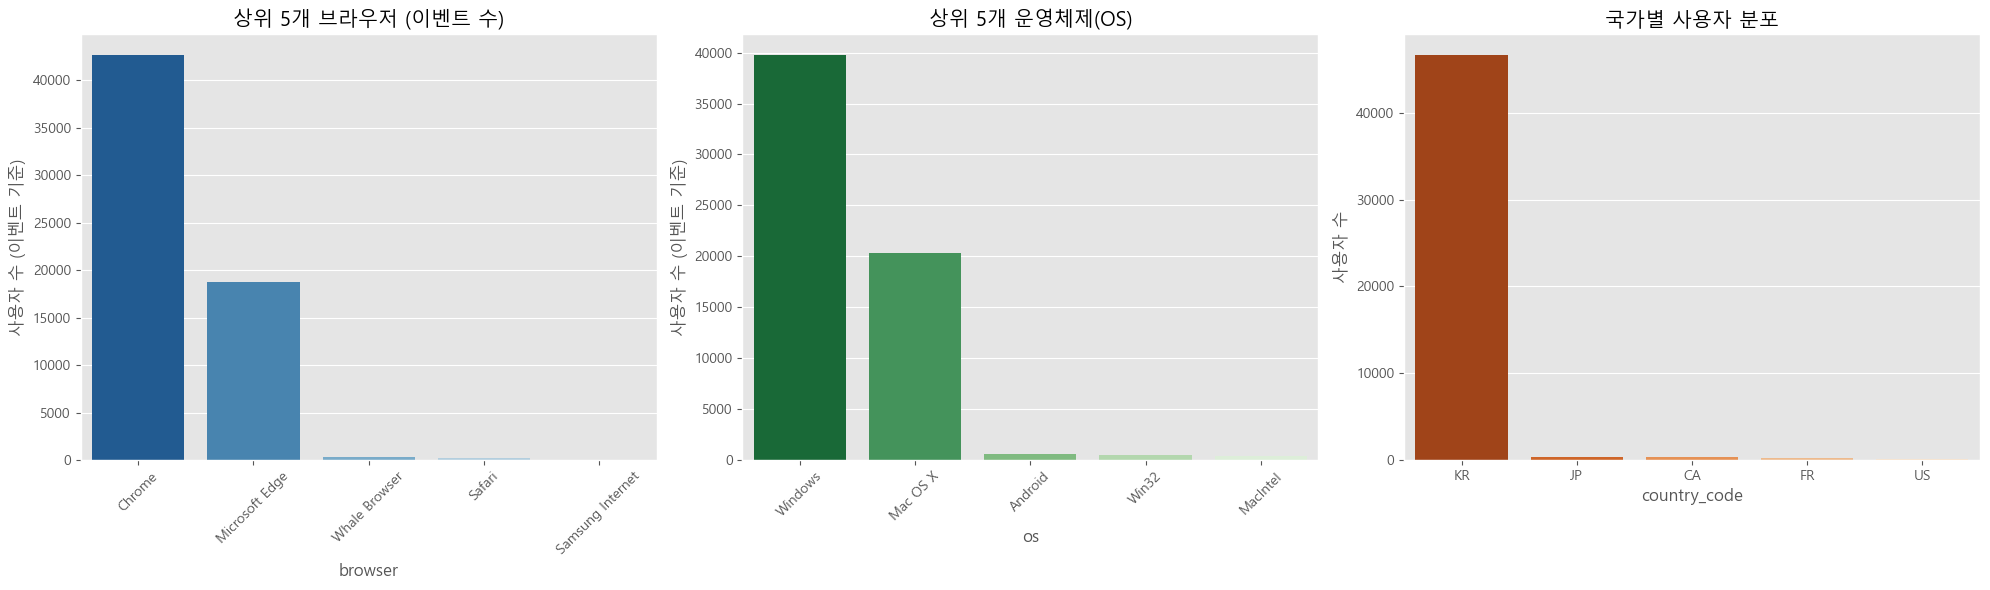

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Browser Top 5
if 'browser' in full_merged.columns:
    browser_counts = full_merged['browser'].value_counts().head(5)
    sns.barplot(x=browser_counts.index, y=browser_counts.values, ax=axes[0], palette='Blues_r')
    axes[0].set_title('상위 5개 브라우저 (이벤트 수)')
    axes[0].set_ylabel('사용자 수 (이벤트 기준)')
    axes[0].tick_params(axis='x', rotation=45)

# 2. OS Top 5
if 'os' in full_merged.columns:
    os_counts = full_merged['os'].value_counts().head(5)
    sns.barplot(x=os_counts.index, y=os_counts.values, ax=axes[1], palette='Greens_r')
    axes[1].set_title('상위 5개 운영체제(OS)')
    axes[1].set_ylabel('사용자 수 (이벤트 기준)')
    axes[1].tick_params(axis='x', rotation=45)

# 3. Country Distribution
geo_col = 'country_code' if 'country_code' in full_merged.columns else ('mp_country_code' if 'mp_country_code' in full_merged.columns else None)
if geo_col:
    country_counts = full_merged[geo_col].value_counts().head(5)
    sns.barplot(x=country_counts.index, y=country_counts.values, ax=axes[2], palette='Oranges_r')
    axes[2].set_title('국가별 사용자 분포')
    axes[2].set_ylabel('사용자 수')
else:
    axes[2].text(0.5, 0.5, 'Country Info Not Found', ha='center')

plt.tight_layout()
plt.show()

## 사용자 참여도 및 활동 분석 (Engagement)
**"사용자들은 얼마나 자주 들어오는가?"**
- **DAU (Daily Active Users)**: 일별 고유 접속자 수.
- **Usage Per User**: 사용자별 서비스 이용 횟수 분포 (Heavy vs Light Users).

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


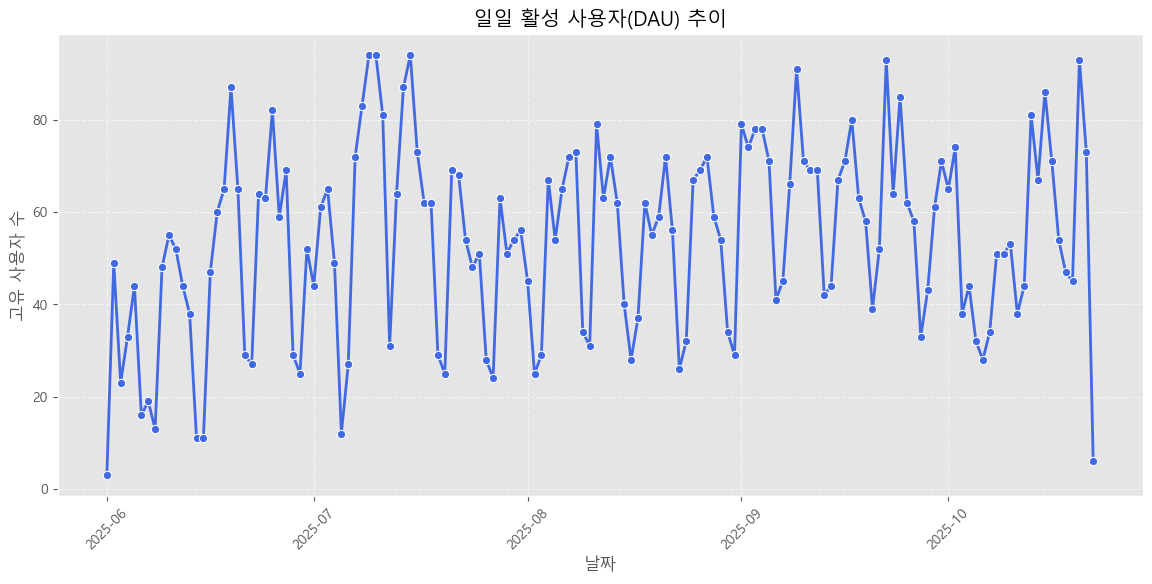

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


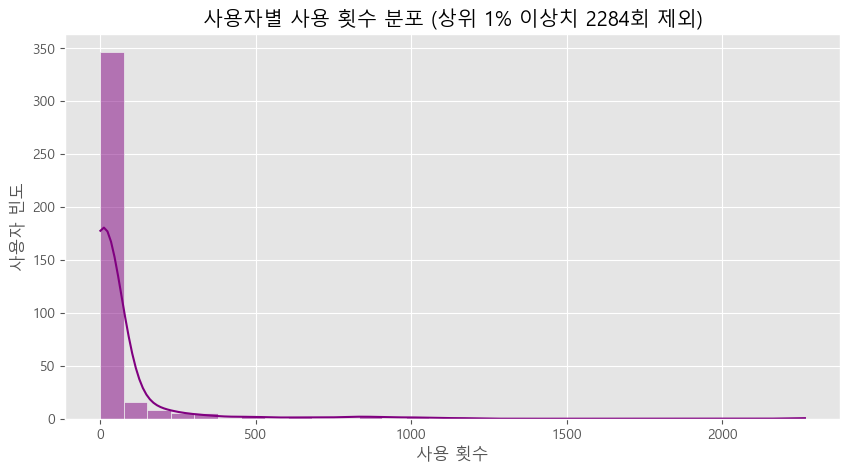

📊 Usage Stats:
count      399.000000
mean       135.285714
std        874.164131
min          1.000000
25%          2.000000
50%          7.000000
75%         28.500000
max      11595.000000
Name: count, dtype: float64


In [5]:
# DAU Trend
if 'datetime' in full_merged.columns:
    full_merged['date_only'] = full_merged['datetime'].dt.date
    dau = full_merged.groupby('date_only')['distinct_id'].nunique()
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(x=dau.index, y=dau.values, marker='o', color='royalblue', linewidth=2)
    plt.title('일일 활성 사용자(DAU) 추이')
    plt.ylabel('고유 사용자 수')
    plt.xlabel('날짜')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.show()

# Usage Histogram (with clipping for outliers)
if 'count' in df_usage.columns:
    usage_counts = df_usage['count'].dropna()
    # Remove extreme outliers (Top 1%) for better visualization
    upper_limit = usage_counts.quantile(0.99)
    filtered_usage = usage_counts[usage_counts <= upper_limit]
    
    plt.figure(figsize=(10, 5))
    sns.histplot(filtered_usage, bins=30, kde=True, color='purple')
    plt.title(f'사용자별 사용 횟수 분포 (상위 1% 이상치 {int(upper_limit)}회 제외)')
    plt.xlabel('사용 횟수')
    plt.ylabel('사용자 빈도')
    plt.show()
    print(f"📊 Usage Stats:\n{usage_counts.describe()}")

## 핵심 성과 지표 (Core KPIs)
서비스의 품질과 사용자 만족도를 나타내는 핵심 지표입니다.

### 생성형 AI 제안 수락률 (Acceptance Rate)
- **정의**: 사용자가 AI가 생성한 문장을 '선택(Select)'한 비율.
- **수식**: `Count(Selected Events) / Count(Run Events) * 100`

🔹 AI 실행 횟수: 40162
🔹 사용자 선택 횟수: 16648
🚀 전체 AI 제안 수락률: 41.45%


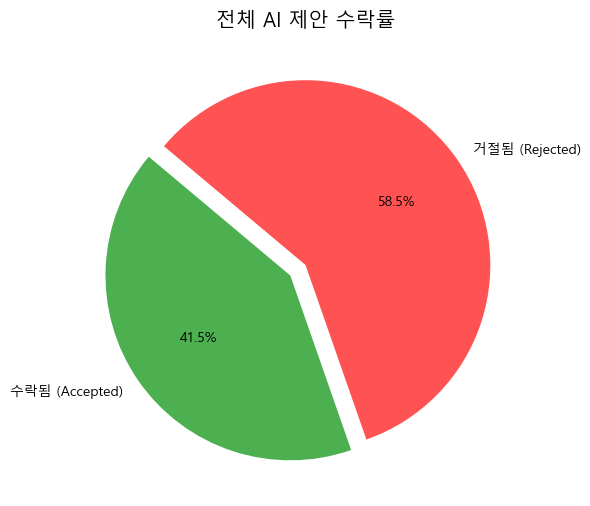

In [6]:
run_events = ['run_paraphrasing', 'editor_run_paraphrasing']
select_events = ['selected_paraphrasing', 'editor_selected_paraphrasing']

df_run = full_merged[full_merged['event_name'].isin(run_events)]
df_select = full_merged[full_merged['event_name'].isin(select_events)]

n_run = len(df_run)
n_select = len(df_select)
acceptance_rate = (n_select / n_run * 100) if n_run > 0 else 0

print(f"🔹 AI 실행 횟수: {n_run}")
print(f"🔹 사용자 선택 횟수: {n_select}")
print(f"🚀 전체 AI 제안 수락률: {acceptance_rate:.2f}%")

# 시각화: 수락률 게이지 (Pie Chart로 표현)
plt.figure(figsize=(6, 6))
plt.pie([n_select, n_run - n_select], labels=['수락됨 (Accepted)', '거절됨 (Rejected)'], 
        autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FF5252'], explode=(0.1, 0))
plt.title('전체 AI 제안 수락률')
plt.show()

### 속성별 성과 분석 (Performance by Segment)
Tone(어조), Field(분야), Position(위치) 등 다양한 컨텍스트에서의 사용성을 비교합니다.

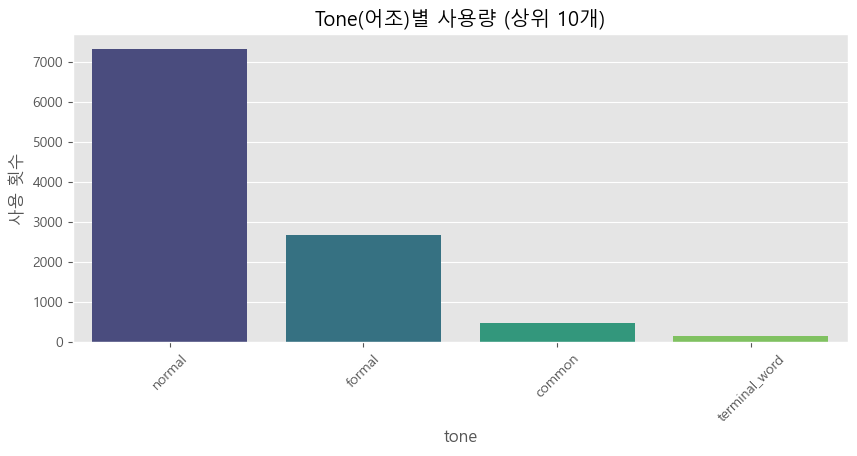

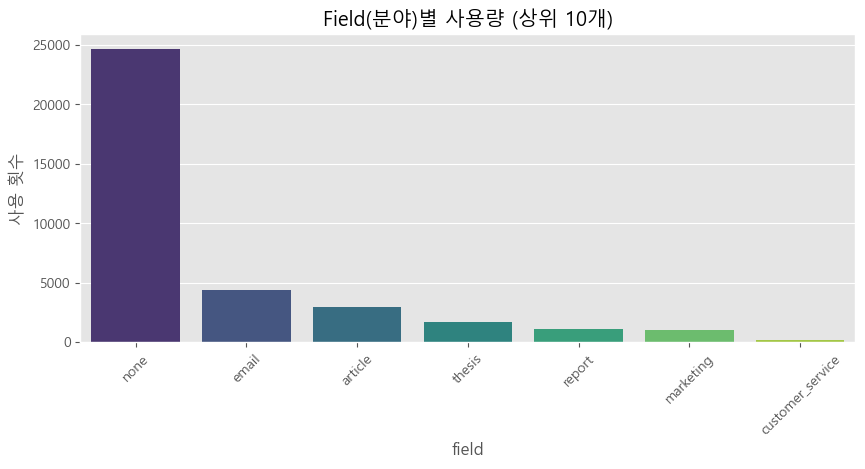

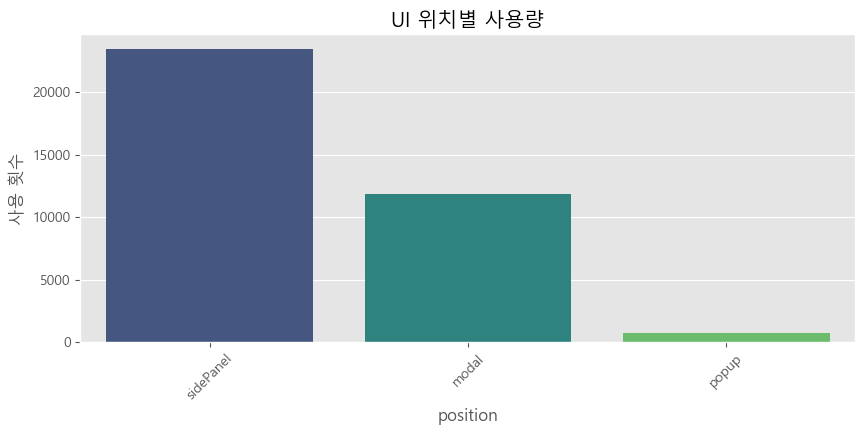

In [7]:
def plot_segment_counts(df, col_keyword, title, n_top=10):
    # 대소문자 무시하고 컬럼 찾기
    target_col = next((c for c in df.columns if col_keyword.lower() in c.lower()), None)
    
    if target_col:
        counts = df[target_col].value_counts().head(n_top)
        plt.figure(figsize=(10, 4))
        sns.barplot(x=counts.index, y=counts.values, palette='viridis')
        plt.title(title)
        plt.xticks(rotation=45)
        plt.ylabel('사용 횟수')
        plt.show()
    else:
        print(f"⚠️ Column containing '{col_keyword}' not found.")

# 1. Tone Analysis
plot_segment_counts(df_run, 'tone', 'Tone(어조)별 사용량 (상위 10개)')

# 2. Field Analysis
plot_segment_counts(df_run, 'field', 'Field(분야)별 사용량 (상위 10개)')

# 3. Position (UI Context)
plot_segment_counts(df_run, 'position', 'UI 위치별 사용량')

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


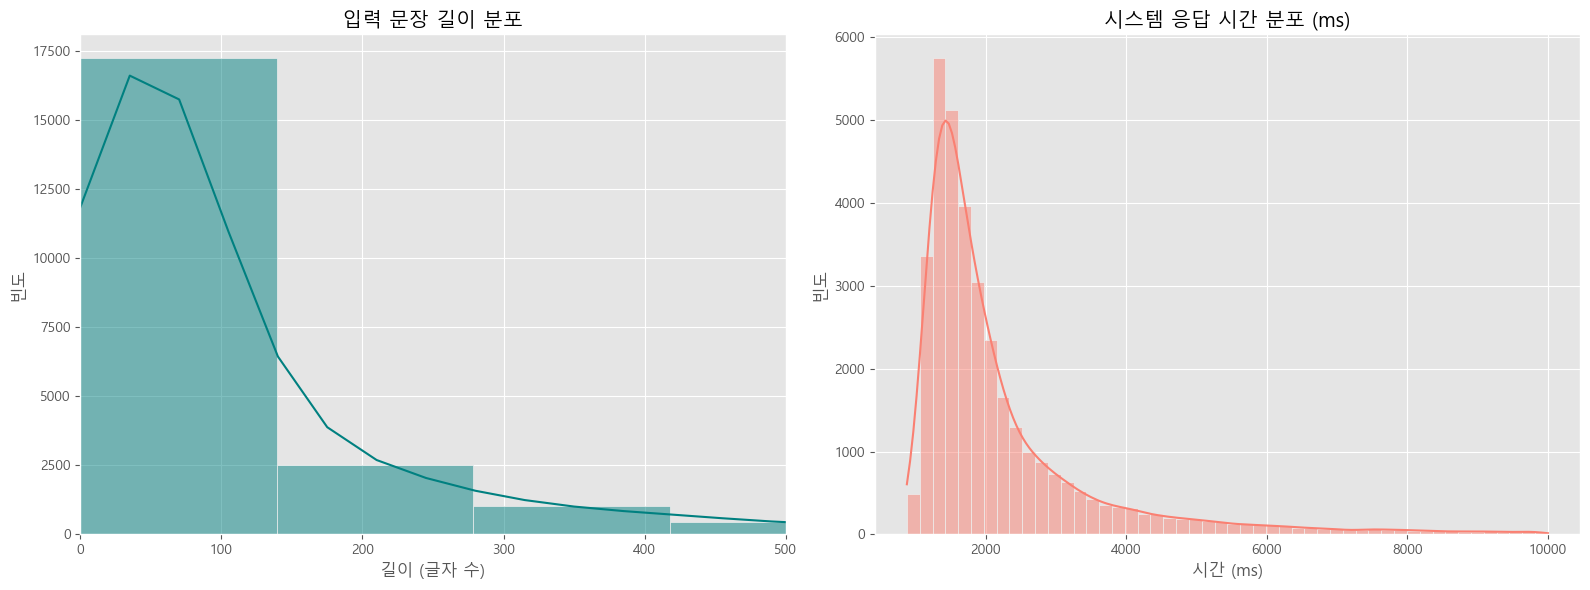

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Input Sentence Length
if 'input_sentence_length' in df_run.columns:
    sns.histplot(df_run['input_sentence_length'].dropna(), bins=50, ax=axes[0], color='teal', kde=True)
    axes[0].set_title('입력 문장 길이 분포')
    axes[0].set_xlabel('길이 (글자 수)')
    axes[0].set_ylabel('빈도')
    axes[0].set_xlim(0, 500) # 가독성을 위해 tail 자르기

# 2. Response Time
if 'response_time_ms' in df_run.columns:
    # Remove outliers for plot clarity (keep < 10000ms)
    resp_times = df_run['response_time_ms'].dropna()
    filtered_times = resp_times[resp_times < 10000]
    
    sns.histplot(filtered_times, bins=50, ax=axes[1], color='salmon', kde=True)
    axes[1].set_title('시스템 응답 시간 분포 (ms)')
    axes[1].set_xlabel('시간 (ms)')
    axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

Found 64 text data files. Processing BLEU scores...


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


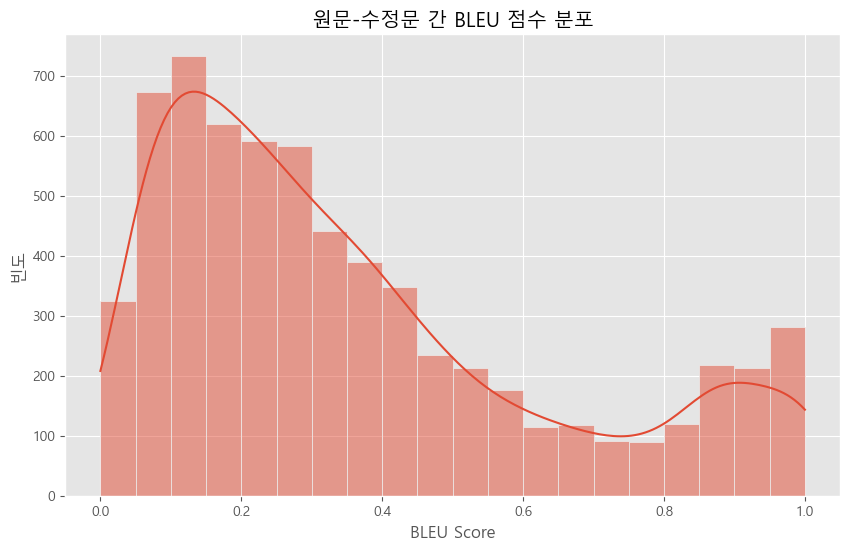

Average BLEU Score: 0.3586


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


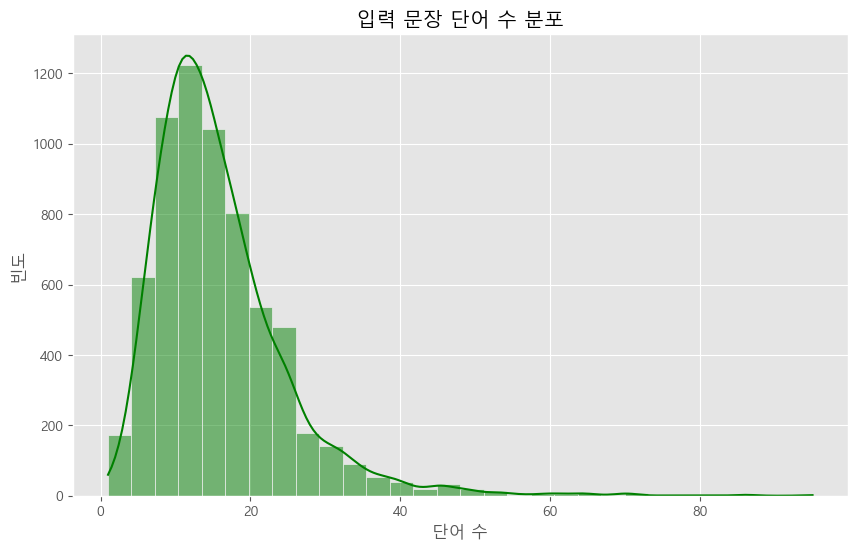

In [14]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
def calculate_bleu(original, modified):
    """
    원문과 수정문 사이의 BLEU 점수를 계산합니다.
    """
    if not isinstance(original, str) or not isinstance(modified, str):
        return 0.0
    
    # 토큰화
    ref = [word_tokenize(original)]
    cand = word_tokenize(modified)
    
    # SmoothingFunction 정의 (chencherry method1 등이 일반적)
    chencherry = SmoothingFunction()
    
    try:
        # smoothing_function=chencherry.method1 추가
        score = sentence_bleu(ref, cand, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
    except:
        score = 0.0
    return score

# munch_data 폴더 경로 설정
munch_data_path = '../data/munch_data/'
csv_files = glob.glob(os.path.join(munch_data_path, '*_matched.csv'))

text_df_list = []

if csv_files:
    print(f"Found {len(csv_files)} text data files. Processing BLEU scores...")
    for file in csv_files:
        try:
            # CSV 로드 (인코딩 에러 방지)
            temp_df = pd.read_csv(file, encoding='utf-8-sig')
            if '원문' in temp_df.columns and '수정문' in temp_df.columns:
                # 결측치 제거
                temp_df = temp_df.dropna(subset=['원문', '수정문'])
                # BLEU 점수 계산
                temp_df['bleu_score'] = temp_df.apply(lambda x: calculate_bleu(x['원문'], x['수정문']), axis=1)
                text_df_list.append(temp_df)
        except Exception as e:
            print(f"Error reading {os.path.basename(file)}: {e}")
    
    if text_df_list:
        merged_text_df = pd.concat(text_df_list, ignore_index=True)
        
        # 시각화: BLEU 점수 분포
        plt.figure(figsize=(10, 6))
        sns.histplot(merged_text_df['bleu_score'], bins=20, kde=True)
        plt.title('원문-수정문 간 BLEU 점수 분포')
        plt.xlabel('BLEU Score')
        plt.ylabel('빈도')
        plt.show()
        
        print(f"Average BLEU Score: {merged_text_df['bleu_score'].mean():.4f}")

        # 시각화: 단어 수 분포
        merged_text_df['word_count'] = merged_text_df['원문'].apply(lambda x: len(str(x).split()))
        plt.figure(figsize=(10, 6))
        sns.histplot(merged_text_df['word_count'], bins=30, kde=True, color='green')
        plt.title('입력 문장 단어 수 분포')
        plt.xlabel('단어 수')
        plt.ylabel('빈도')
        plt.show()

    else:
        print("No valid text dataframes created.")
else:
    print("munch_data folder not found or empty. Skipping Text Deep Dive.")

## 시간대별 활동 분석 (Activity Heatmap)

요일별, 시간대별 사용자 활동 빈도를 시각화하여 사용자가 가장 활발한 시간을 파악합니다.

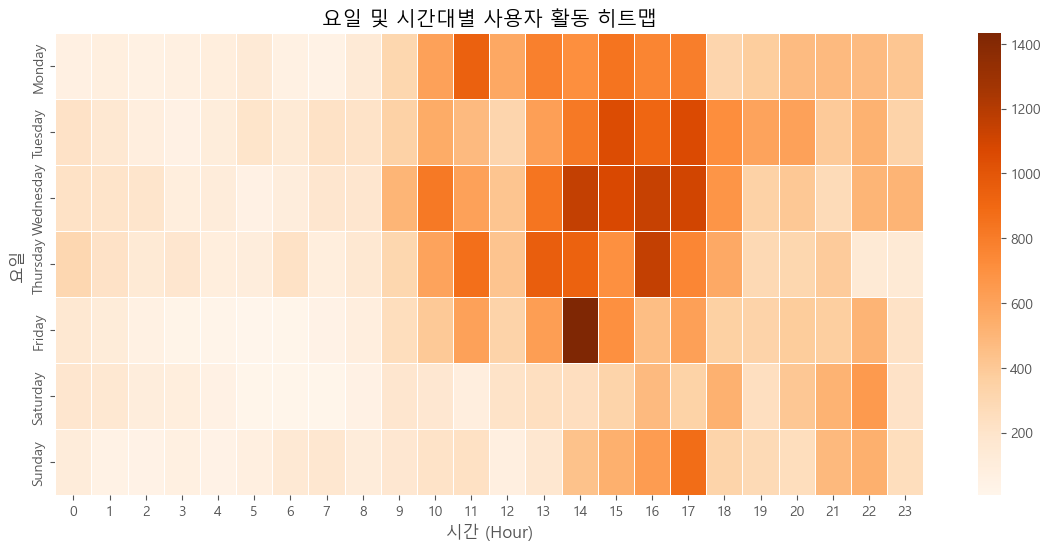

In [11]:
if 'datetime' in full_merged.columns:
    activity_df = full_merged[['datetime']].copy()
    activity_df['day_of_week'] = activity_df['datetime'].dt.day_name()
    activity_df['hour'] = activity_df['datetime'].dt.hour
    
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    activity_pivot = activity_df.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0)
    activity_pivot = activity_pivot.reindex(days_order)
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(activity_pivot, cmap='Oranges', linewidths=0.5)
    plt.title('요일 및 시간대별 사용자 활동 히트맵')
    plt.xlabel('시간 (Hour)')
    plt.ylabel('요일')
    plt.show()
else:
    print("Activity heatmap skipped due to missing timestamp data.")

## 상관관계 분석 (Correlation Analysis)

주요 수치형 변수(글자 수, 응답 시간 등) 간의 상관관계를 분석합니다.

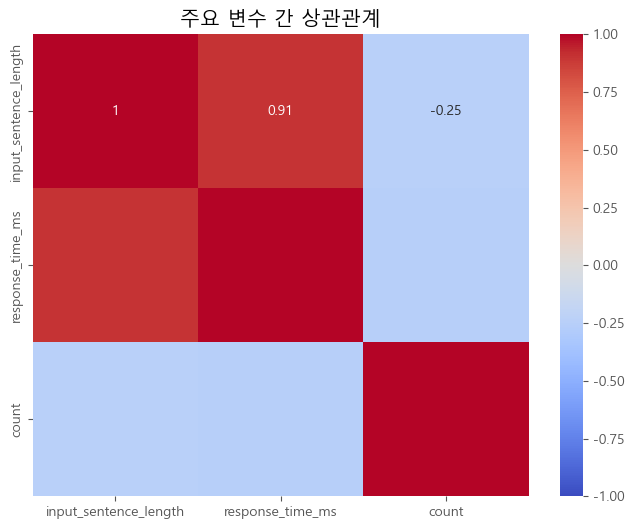

In [12]:
numeric_cols = ['input_sentence_length', 'response_time_ms', 'count']
available_cols = [col for col in numeric_cols if col in full_merged.columns]

if len(available_cols) >= 2:
    corr_matrix = full_merged[available_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('주요 변수 간 상관관계')
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")